In [2]:
from google.colab import auth
from google.cloud import bigquery
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

auth.authenticate_user()

# Read Data

In [3]:
client = bigquery.Client(project="alterdata-rekrutacja-28")

query_cost_revenue = """ SELECT * FROM `alterdata-rekrutacja-scientist.marketing_data.cost_revenue` """
query_promotions = """ SELECT * FROM `alterdata-rekrutacja-scientist.marketing_data.promotions` """
cost_revenue_df = client.query(query_cost_revenue).to_dataframe()
promotions_df = client.query(query_promotions).to_dataframe()
cost_revenue_df.head()

,week,geo,impression_tiktok,impression_tv,impression_outdoor1,impression_google,impression_facebook,impression_outdoor2,impression_organic,market_share,cost_tiktok,cost_tv,cost_outdoor1,cost_google,cost_facebook,cost_outdoor2,conversions,revenue,population
0,2022-10-03,Geo0,495955,323000,24000,895616,241546,<NA>,156720,0.044674,3636.700700000,3113.394800000,180.460000000,6979.392600000,1882.105100000,387.499424,2193336.500000000,43971.176684130,136670.940000000
1,2022-09-26,Geo0,316706,408000,168000,944990,384225,<NA>,304060,0.058172,2322.317400000,3935.714600000,1250.409200000,7364.156700000,2993.847200000,2254.286274,2972293.800000000,59492.778796164,136670.940000000
2,2023-09-11,Geo0,124229,229000,99000,865630,412929,<NA>,152068,0.046063,910.936900000,2210.368000000,736.687000000,6745.716300000,3217.506300000,1270.646476,2624217.500000000,52411.097592705,136670.940000000
3,2022-03-14,Geo0,306297,341000,200000,647233,525200,<NA>,243823,0.052139,2245.991000000,3288.682000000,1483.368700000,5043.783700000,4092.312000000,2764.278692,2489067.200000000,49671.297360954,136670.940000000
4,2022-08-22,Geo0,287110,575000,175000,274969,429373,<NA>,382009,0.057232,2105.298300000,5546.928700000,1303.451000000,2142.789600000,3345.636500000,2161.070642,2840257.200000000,56950.417475266,136670.940000000


In [4]:
promotions_df.head()

,week,geo,promo_description
0,2021-12-13,Geo15,-20% rabatu na całe zamówienie po przekroczeni...
1,2022-11-21,Geo16,-20% rabatu na całe zamówienie po przekroczeni...
2,2023-11-06,Geo31,-20% rabatu na całe zamówienie po przekroczeni...
3,2021-02-08,Geo34,-20% rabatu na całe zamówienie po przekroczeni...
4,2021-06-21,Geo4,-20% rabatu na całe zamówienie po przekroczeni...


# EDA

In [5]:
cost_revenue_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6200 entries, 0 to 6199
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   week                 6200 non-null   dbdate 
 1   geo                  6200 non-null   object 
 2   impression_tiktok    6200 non-null   Int64  
 3   impression_tv        5874 non-null   Int64  
 4   impression_outdoor1  6200 non-null   Int64  
 5   impression_google    6200 non-null   Int64  
 6   impression_facebook  6200 non-null   Int64  
 7   impression_outdoor2  0 non-null      Int64  
 8   impression_organic   6200 non-null   Int64  
 9   market_share         6200 non-null   float64
 10  cost_tiktok          6200 non-null   object 
 11  cost_tv              6200 non-null   object 
 12  cost_outdoor1        6200 non-null   object 
 13  cost_google          6200 non-null   object 
 14  cost_facebook        6200 non-null   object 
 15  cost_outdoor2        6200 non-null   f

In [6]:
promotions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3299 entries, 0 to 3298
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   week               3299 non-null   dbdate
 1   geo                3299 non-null   object
 2   promo_description  3299 non-null   object
dtypes: dbdate(1), object(2)
memory usage: 77.4+ KB


In [7]:
# add promotions and promotions flag to cost_revenue df
promotions_df["promo"] = 1
cost_revenue_df = pd.merge(cost_revenue_df, promotions_df, on=["geo", "week"], how="left")
cost_revenue_df["promo"] = cost_revenue_df["promo"].fillna(0)

In [8]:
# change data type to numeric
for col in ["cost_tiktok", "cost_tv", "cost_outdoor1", "cost_google", "cost_facebook", "conversions", "revenue", "population"]:
    cost_revenue_df[col] = pd.to_numeric(cost_revenue_df[col], errors="coerce")

In [9]:
# global sanity ckeck
channels = {
    "tv": ("cost_tv", "impression_tv"),
    "outdoor1": ("cost_outdoor1", "impression_outdoor1"),
    "outdoor2": ("cost_outdoor2", "impression_outdoor2"),
    "google": ("cost_google", "impression_google"),
    "meta": ("cost_facebook", "impression_facebook"),
    "tiktok": ("cost_tiktok", "impression_tiktok"),
}
sanity_check = {}

for channel, (cost_col, imp_col) in channels.items():
    mask = (cost_revenue_df[cost_col] == 0) & (cost_revenue_df[imp_col] > 0)
    sanity_check[channel] = mask.sum()

pd.Series(sanity_check, name="cases_cost_0_impression_gt_0")

,cases_cost_0_impression_gt_0
tv,0
outdoor1,0
outdoor2,0
google,0
meta,0
tiktok,0


## Handle Missing Value
Missing values ​​in the columns impression_tv and impression_outdoor_2 will be filled in based on the ratio in each region, i.e. impressions per PLN 1. The impression_outdoor_1 column will be used to fill the impression_outdoor_2 column.

In [10]:
cost_revenue_df.describe()

,impression_tiktok,impression_tv,impression_outdoor1,impression_google,impression_facebook,impression_outdoor2,impression_organic,market_share,cost_tiktok,cost_tv,cost_outdoor1,cost_google,cost_facebook,cost_outdoor2,conversions,revenue,population,promo
count,6200.0,5874.0,6200.0,6200.0,6200.0,0.0,6200.0,6200.000000,6200.000000,6200.000000,6200.000000,6200.000000,6200.000000,6200.000000,6.200000e+03,6200.000000,6200.000000,6200.000000
mean,885854.729032,518135.682669,261643.870968,1807384.852903,978975.768871,<NA>,533079.585323,0.051430,6495.727472,5015.920660,1944.260233,14084.661852,7628.092645,3570.458824,1.056983e+07,211411.187201,542418.832750,0.532097
std,819983.122866,620071.852125,556307.221833,1305215.558778,913499.318768,<NA>,696349.328102,0.019060,6012.709228,5985.940739,4133.877448,10171.336645,7117.905927,7663.839075,6.083582e+06,121688.348393,242839.845445,0.499009
min,0.0,0.0,0.0,0.0,0.0,<NA>,0.0,0.005675,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.840312e+05,9742.282233,136670.940000,0.000000
25%,253368.75,0.0,0.0,808356.5,265916.75,<NA>,0.0,0.038792,1857.882850,0.000000,0.000000,6299.393250,2071.999900,0.000000,5.718118e+06,114323.174381,335176.345000,0.000000
50%,679840.5,308500.0,0.0,1506463.5,741981.0,<NA>,270682.0,0.050229,4985.082000,2984.910850,0.000000,11739.630000,5781.450450,0.000000,9.705633e+06,193969.173224,560478.825000,1.000000
75%,1325314.75,799000.0,256250.0,2566897.5,1474323.25,<NA>,800399.75,0.062442,9718.165750,7783.443250,1906.635875,20003.423750,11487.796750,3472.400088,1.439251e+07,287918.213647,736033.810000,1.000000
max,5192032.0,4398000.0,5610000.0,7635147.0,6975542.0,<NA>,5801781.0,0.167090,38071.730000,42397.700000,41688.645000,59499.484000,54352.810000,73356.957366,3.671269e+07,739823.338940,994048.940000,1.000000


In [11]:
# check if the missing data is related only to some region
missing_by_geo = (
    cost_revenue_df.groupby("geo")
      .apply(lambda x: x.isnull().mean())
)

missing_by_geo[["impression_tv", "impression_outdoor2"]]

/tmp/ipython-input-1344883995.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.isnull().mean())


,impression_tv,impression_outdoor2
geo,,
Geo0,0.038710,1.0
Geo1,0.051613,1.0
Geo10,0.083871,1.0
Geo11,0.096774,1.0
Geo12,0.032258,1.0
Geo13,0.070968,1.0
Geo14,0.038710,1.0
Geo15,0.032258,1.0
Geo16,0.025806,1.0


In [12]:
cost_revenue_df[cost_revenue_df["impression_tv"].isnull()].head(5)

,week,geo,impression_tiktok,impression_tv,impression_outdoor1,impression_google,impression_facebook,impression_outdoor2,impression_organic,market_share,...,cost_tv,cost_outdoor1,cost_google,cost_facebook,cost_outdoor2,conversions,revenue,population,promo_description,promo
18,2022-07-04,Geo0,566751,<NA>,149000,380696,379788,<NA>,161962,0.073185,...,0.0000,1107.066500,2966.7034,2959.27440,2359.344676,3017796.8,60265.761214,136670.94,Wszystkie produkty z poprzedniego sezonu -40%.,1.0
35,2023-11-06,Geo0,176909,<NA>,235000,546091,305829,<NA>,131601,0.037811,...,1150.3629,1743.421300,4255.6000,2382.99240,2704.800929,2062280.5,41311.380250,136670.94,NaN,0.0
40,2023-03-27,Geo0,75067,<NA>,1000,492758,30509,<NA>,74603,0.071866,...,2680.2144,7.274875,3839.9846,237.72343,10.761971,2713922.2,54572.511040,136670.94,NaN,0.0
41,2022-10-17,Geo0,185487,<NA>,366000,984345,738102,<NA>,441399,0.029491,...,2022.5278,2722.282000,7670.8433,5751.22560,4695.346823,1778753.1,35654.212955,136670.94,NaN,0.0
71,2024-01-01,Geo1,897814,<NA>,448000,891343,307507,<NA>,575692,0.051260,...,3506.3230,3332.256800,6946.0940,2396.06710,5788.918810,3207906.5,64220.581524,199816.90,Darmowa dostawa na wszystkie zamówienia przez ...,1.0


In [13]:
# Insert 0 impression into missing data where cost is 0
cost_revenue_df.loc[
    (cost_revenue_df["cost_tv"] == 0) & (cost_revenue_df["impression_tv"].isna()),
    ["geo", "week", "cost_tv", "impression_tv"]
].shape[0]

cost_revenue_df.loc[cost_revenue_df["cost_tv"] == 0, "impression_tv"] = 0

cost_revenue_df.loc[
    (cost_revenue_df["cost_outdoor2"] == 0) & (cost_revenue_df["impression_outdoor2"].isna()),
    ["geo", "week", "cost_outdoor2", "impression_outdoor2"]
].shape[0]

cost_revenue_df.loc[cost_revenue_df["cost_outdoor2"] == 0, "impression_outdoor2"] = 0

In [14]:
# fill in missing values ​​using ratio in the impression_tv column
tv_ratio = (
    cost_revenue_df
    .loc[cost_revenue_df["impression_tv"].notna() & cost_revenue_df["cost_tv"].notna() & cost_revenue_df["cost_tv"] != 0]
    .assign(ratio=lambda x: x["impression_tv"] / x["cost_tv"])
    .groupby("geo")["ratio"]
    .median()
)
tv_ratio

mask_tv = cost_revenue_df["impression_tv"].isna() & cost_revenue_df["cost_tv"].notna()

cost_revenue_df.loc[mask_tv, "impression_tv"] = (
    np.floor(cost_revenue_df.loc[mask_tv, "geo"].map(tv_ratio)* cost_revenue_df.loc[mask_tv, "cost_tv"])
)

In [15]:
outdoor1_ratio = (
    cost_revenue_df
    .loc[cost_revenue_df["impression_outdoor1"].notna() & cost_revenue_df["cost_outdoor1"].notna() & cost_revenue_df["cost_outdoor1"] != 0]
    .assign(ratio=lambda x: x["impression_outdoor1"] / x["cost_outdoor1"])
    .groupby("geo")["ratio"]
    .median()
)

mask_out2 = (
    cost_revenue_df["impression_outdoor2"].isna() &
    cost_revenue_df["cost_outdoor2"].notna()
)

cost_revenue_df.loc[mask_out2, "impression_outdoor2"] = (
    np.floor(cost_revenue_df.loc[mask_out2, "geo"].map(outdoor1_ratio) * cost_revenue_df.loc[mask_out2, "cost_outdoor2"])
)

In [16]:
cost_revenue_df[["impression_tv", "impression_outdoor2"]].isna().sum()

,0
impression_tv,0
impression_outdoor2,0


## Check time ranges at the geo level
The aim of this section is to poerform comparison to see if the same time frame exists for each location.

In [17]:
cost_revenue_df["geo"].unique()

array(['Geo0', 'Geo1', 'Geo10', 'Geo11', 'Geo12', 'Geo13', 'Geo14',
       'Geo15', 'Geo16', 'Geo17', 'Geo18', 'Geo19', 'Geo2', 'Geo20',
       'Geo21', 'Geo22', 'Geo23', 'Geo24', 'Geo25', 'Geo26', 'Geo27',
       'Geo28', 'Geo29', 'Geo3', 'Geo30', 'Geo31', 'Geo32', 'Geo33',
       'Geo34', 'Geo35', 'Geo36', 'Geo37', 'Geo38', 'Geo39', 'Geo4',
       'Geo5', 'Geo6', 'Geo7', 'Geo8', 'Geo9'], dtype=object)

In [18]:
print(f"Cost-revenue table time range: {cost_revenue_df["week"].min()}, {cost_revenue_df["week"].max()}")
print(f"Promotions table time range: {promotions_df["week"].min()}, {promotions_df["week"].max()}")

Cost-revenue table time range: 2021-01-25, 2024-01-15
Promotions table time range: 2021-01-25, 2024-01-15


In [19]:
# check if there is the same time range for each region
period_per_geo = (
    cost_revenue_df.groupby("geo")["week"]
      .agg(min_week="min", max_week="max", n_weeks="nunique")
      .reset_index()
)

period_per_geo

,geo,min_week,max_week,n_weeks
0,Geo0,2021-01-25,2024-01-15,155
1,Geo1,2021-01-25,2024-01-15,155
2,Geo10,2021-01-25,2024-01-15,155
3,Geo11,2021-01-25,2024-01-15,155
4,Geo12,2021-01-25,2024-01-15,155
5,Geo13,2021-01-25,2024-01-15,155
6,Geo14,2021-01-25,2024-01-15,155
7,Geo15,2021-01-25,2024-01-15,155
8,Geo16,2021-01-25,2024-01-15,155
9,Geo17,2021-01-25,2024-01-15,155


In [20]:
# check whether the population is unique in the region
cost_revenue_df.groupby("geo")["population"].nunique().sort_values(ascending=False)

,population
geo,
Geo0,1
Geo1,1
Geo10,1
Geo11,1
Geo12,1
Geo13,1
Geo14,1
Geo15,1
Geo16,1


## Time series analysis - EDA Insight
This section helps us understand how sales change over time, ow marketing costs correlate with sales, which channels "look promising" even before the model and what the impact of the promotions is.

EDA doesn't provide cause-and-effect relationships, but it does provide hypotheses and allows us to reject bad ideas before modeling.

In [21]:
# weekly = (
#     cost_revenue_df
#     .groupby("week")
#     .agg(
#         revenue=("revenue", "sum"),
#         conversions=("conversions", "sum"),
#         cost_tv=("cost_tv", "sum"),
#         cost_google=("cost_google", "sum"),
#         cost_facebook=("cost_facebook", "sum"),
#         cost_tiktok=("cost_tiktok", "sum"),
#         cost_outdoor1=("cost_outdoor1", "sum"),
#         cost_outdoor2=("cost_outdoor2", "sum"),
#         promo_weeks=("promo", "sum")
#     )
#     .reset_index()
# )

weekly = (
    cost_revenue_df
    .groupby("week", as_index=False)
    .sum(numeric_only=True)
)

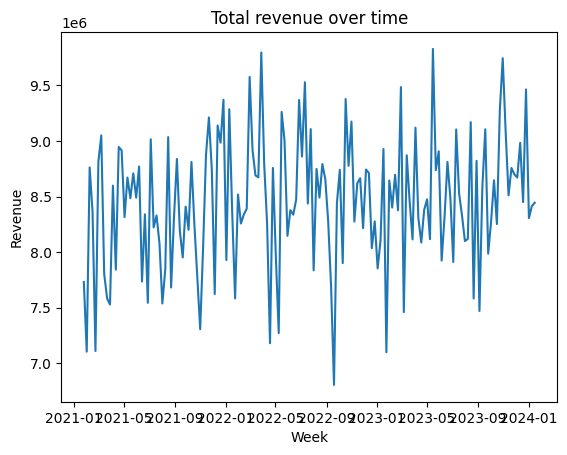

In [22]:
plt.figure()
plt.plot(weekly["week"], weekly["revenue"])
plt.xlabel("Week")
plt.ylabel("Revenue")
plt.title("Total revenue over time")
plt.show()

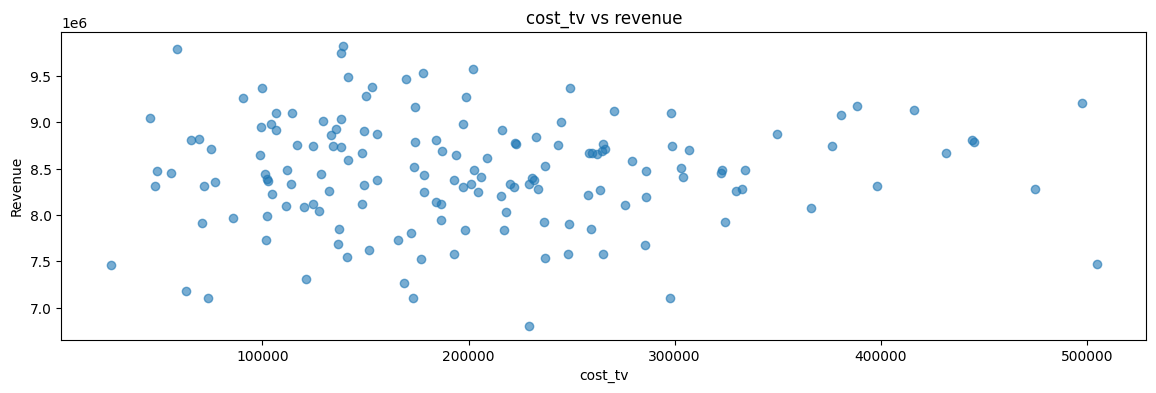

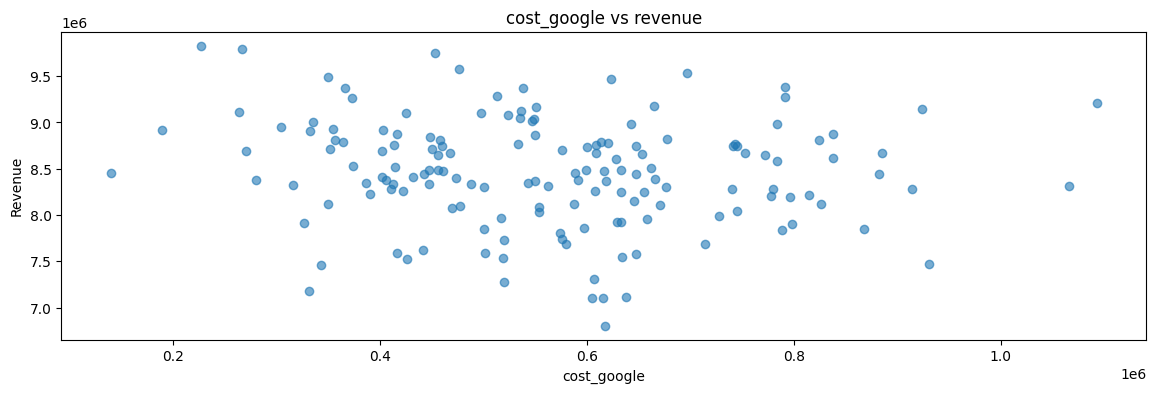

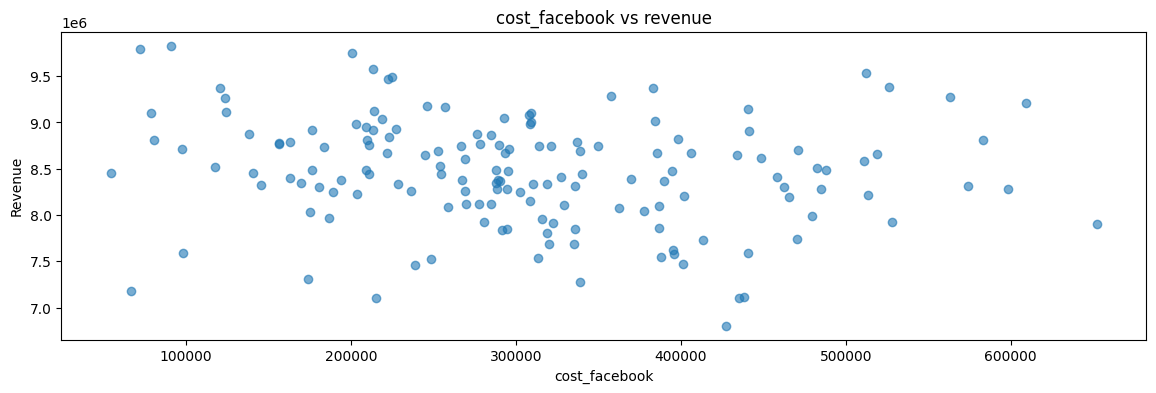

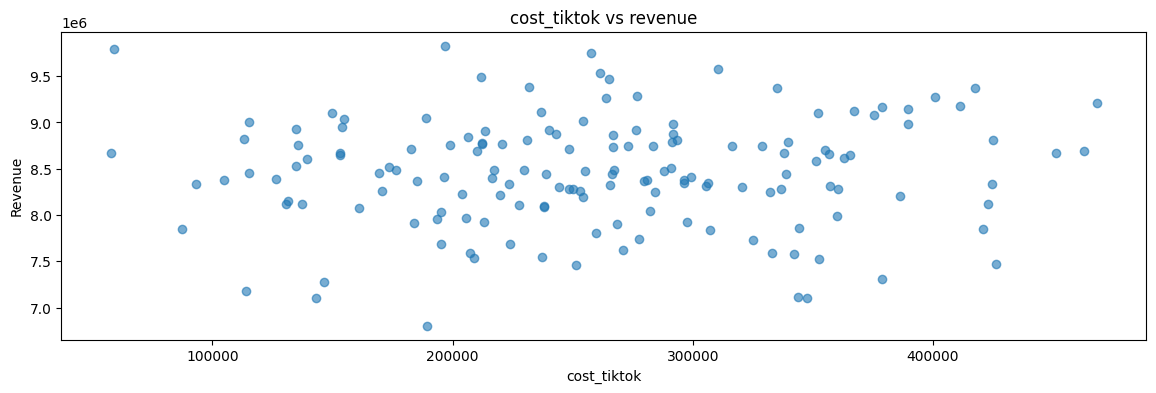

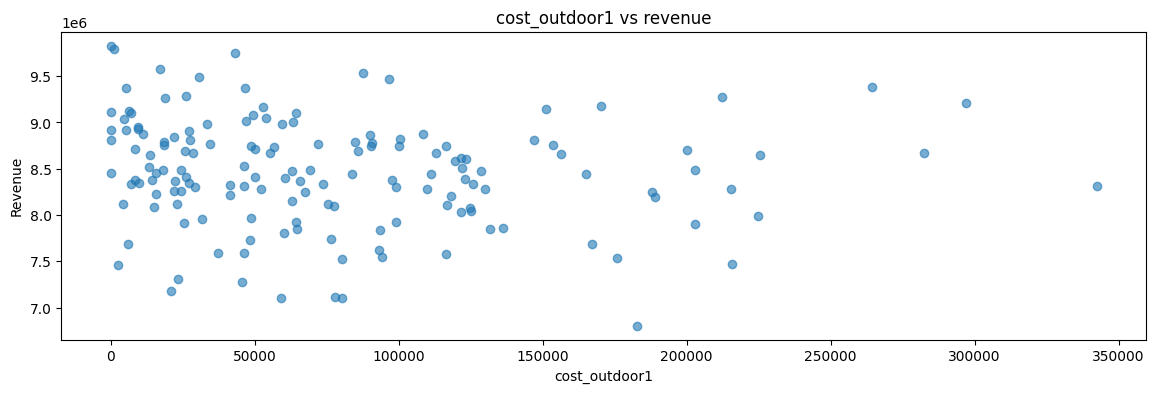

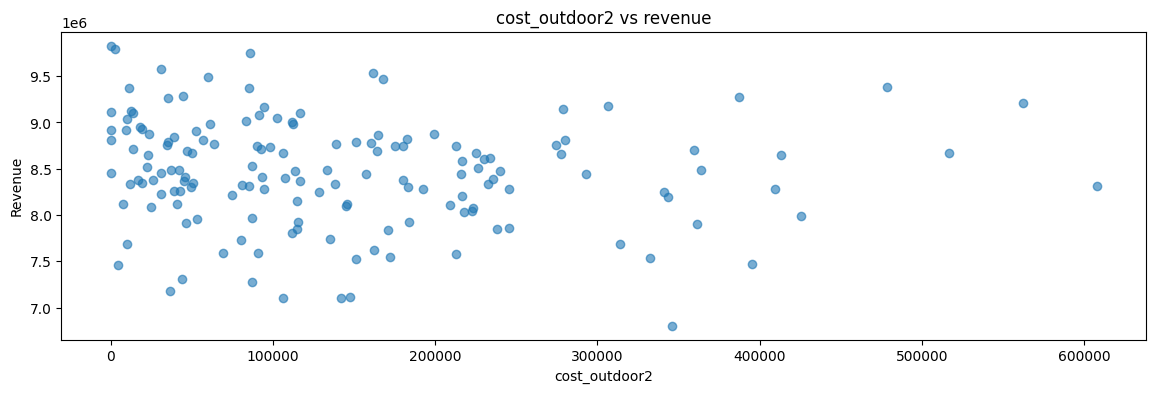

In [23]:
channels = {
    "TV": "cost_tv",
    "Google Ads": "cost_google",
    "Facebook Ads": "cost_facebook",
    "TikTok Ads": "cost_tiktok",
    "Outdoor 1": "cost_outdoor1",
    "Outdoor 2": "cost_outdoor2",
}

for channel, cost_col in channels.items():
    plt.figure(figsize=(14, 4))

    plt.scatter(weekly[cost_col], weekly["revenue"], alpha=0.6)
    plt.xlabel(cost_col)
    plt.ylabel("Revenue")
    plt.title(f"{cost_col} vs revenue")
    plt.show()

    # plt.plot(
    #     weekly["week"],
    #     weekly["revenue"]/10,
    #     label="Revenue",
    #     linewidth=3
    # )

    # plt.plot(
    #     weekly["week"],
    #     weekly[cost_col],
    #     label=f"{channel} cost",
    #     linewidth=2
    # )

    # plt.title(f"Revenue vs {channel} cost (weekly)")
    # plt.xlabel("Week")
    # plt.ylabel("Value")
    # plt.legend()
    # plt.tight_layout()
    # plt.show()

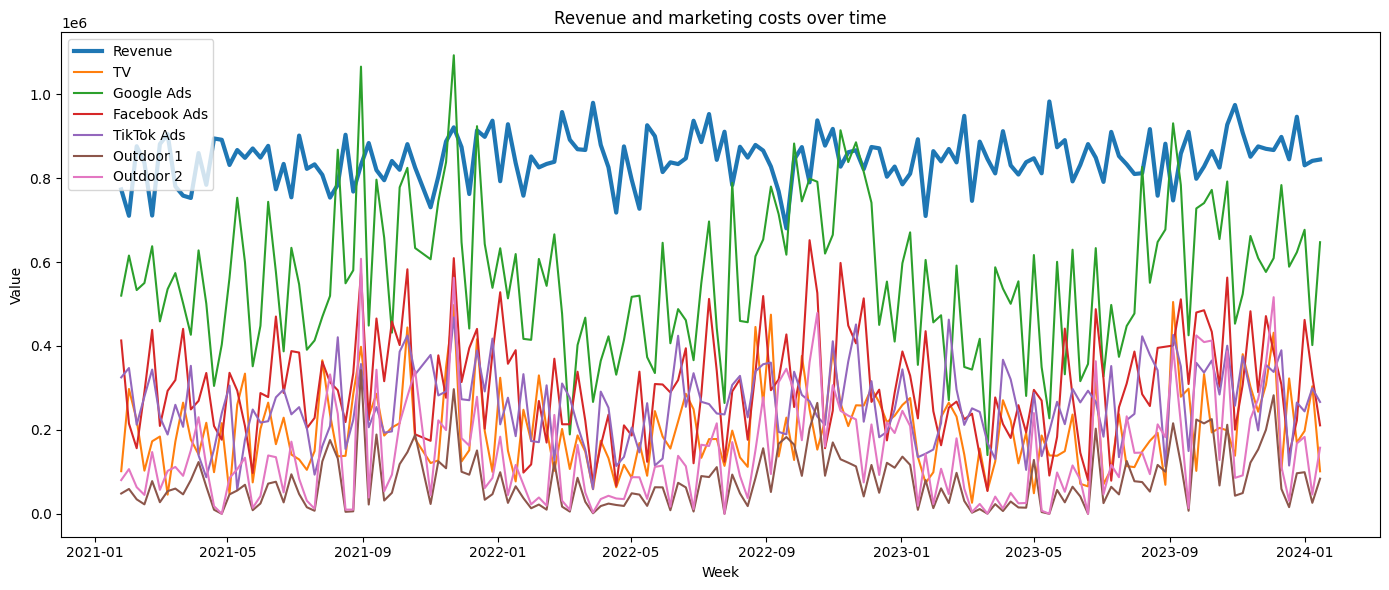

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(weekly["week"], weekly["revenue"]/10, label="Revenue", linewidth=3)

plt.plot(weekly["week"], weekly["cost_tv"], label="TV")
plt.plot(weekly["week"], weekly["cost_google"], label="Google Ads")
plt.plot(weekly["week"], weekly["cost_facebook"], label="Facebook Ads")
plt.plot(weekly["week"], weekly["cost_tiktok"], label="TikTok Ads")
plt.plot(weekly["week"], weekly["cost_outdoor1"], label="Outdoor 1")
plt.plot(weekly["week"], weekly["cost_outdoor2"], label="Outdoor 2")

plt.xlabel("Week")
plt.ylabel("Value")
plt.title("Revenue and marketing costs over time")
plt.legend()
plt.tight_layout()
plt.show()


In [25]:
corr_cols = [
    "revenue",
    "conversions",
    "cost_tv",
    "cost_google",
    "cost_facebook",
    "cost_tiktok",
    "cost_outdoor1",
    "cost_outdoor2",
    "promo"
]

weekly[corr_cols].corr()["revenue"].sort_values(ascending=False)


,revenue
revenue,1.000000
conversions,0.999924
promo,0.263049
cost_tiktok,0.048281
cost_tv,0.014280
cost_outdoor2,-0.114033
cost_outdoor1,-0.115081
cost_google,-0.124931
cost_facebook,-0.174199


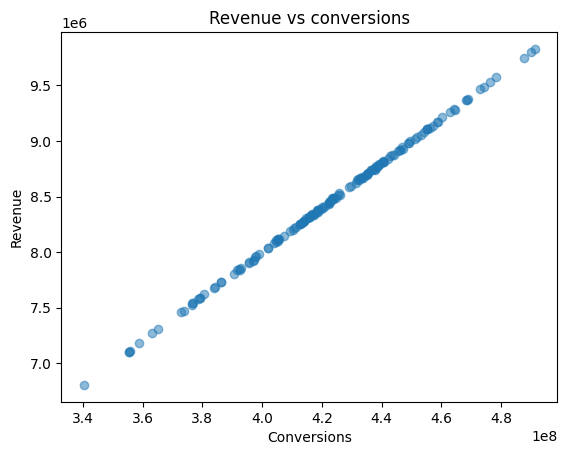

In [26]:
plt.figure()
plt.scatter(weekly["conversions"], weekly["revenue"], alpha=0.5)
plt.xlabel("Conversions")
plt.ylabel("Revenue")
plt.title("Revenue vs conversions")
plt.show()

conversions i revenue są bardzo skorelowane, dlatego conversions należy usunąć przed modelowaniem!

In [27]:
weekly["is_promo"] = weekly["promo"] > 0

weekly.groupby("is_promo")["revenue"].describe()


,count,mean,std,min,25%,50%,75%,max
is_promo,,,,,,,,
True,155.0,8.456447e+06,584439.059372,6.805080e+06,8.115494e+06,8.457473e+06,8.813237e+06,9.828881e+06


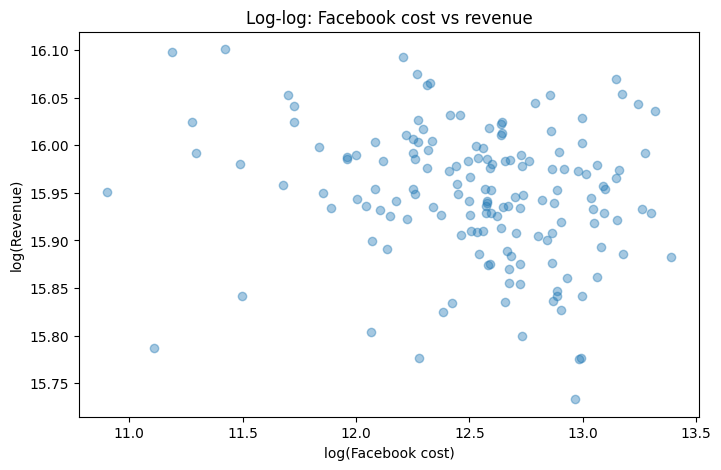

In [28]:
plt.figure(figsize=(8,5))
plt.scatter(
    np.log1p(weekly["cost_facebook"]),
    np.log1p(weekly["revenue"]),
    alpha=0.4
)
plt.xlabel("log(Facebook cost)")
plt.ylabel("log(Revenue)")
plt.title("Log-log: Facebook cost vs revenue")
plt.show()

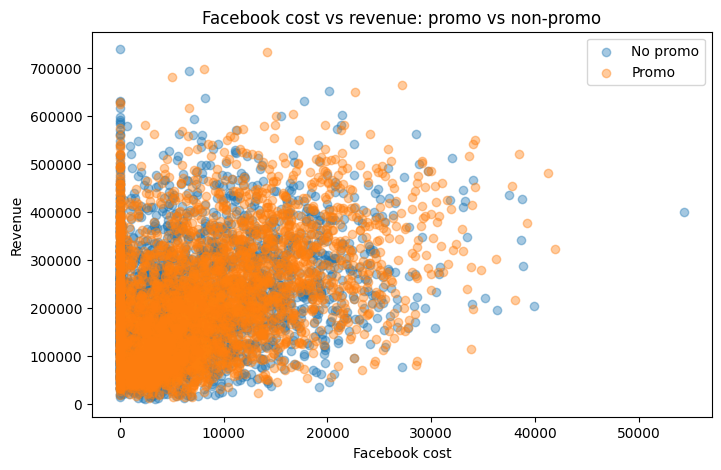

In [29]:
plt.figure(figsize=(8,5))
df_imputed = cost_revenue_df
plt.scatter(
    df_imputed.loc[df_imputed["promo"] == 0, "cost_facebook"],
    df_imputed.loc[df_imputed["promo"] == 0, "revenue"],
    alpha=0.4,
    label="No promo"
)

plt.scatter(
    df_imputed.loc[df_imputed["promo"] == 1, "cost_facebook"],
    df_imputed.loc[df_imputed["promo"] == 1, "revenue"],
    alpha=0.4,
    label="Promo"
)

plt.legend()
plt.xlabel("Facebook cost")
plt.ylabel("Revenue")
plt.title("Facebook cost vs revenue: promo vs non-promo")
plt.show()


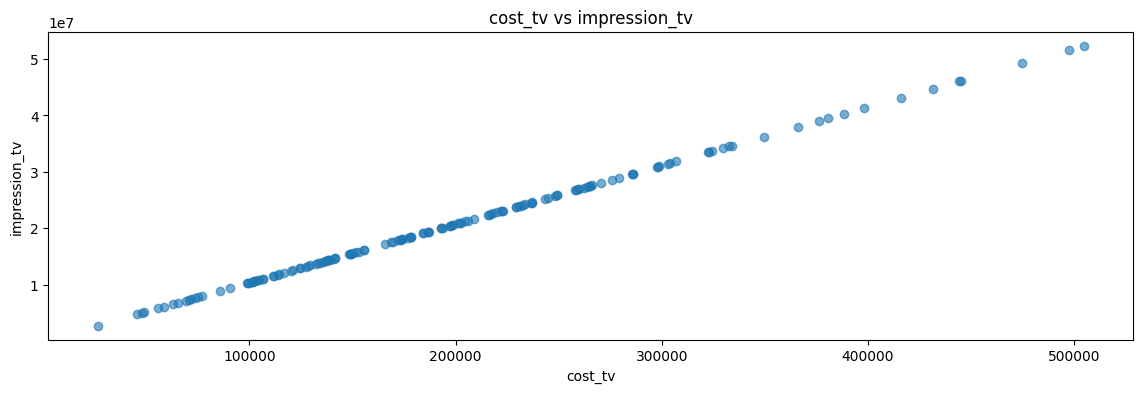

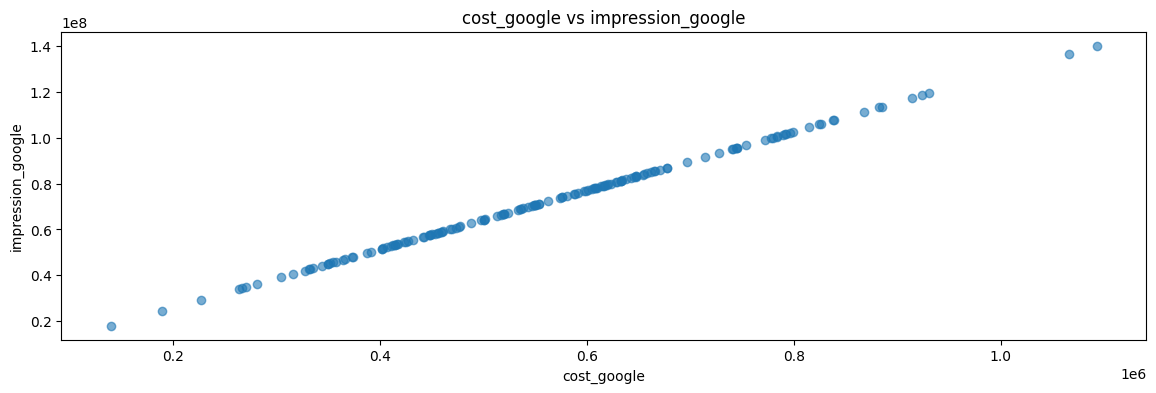

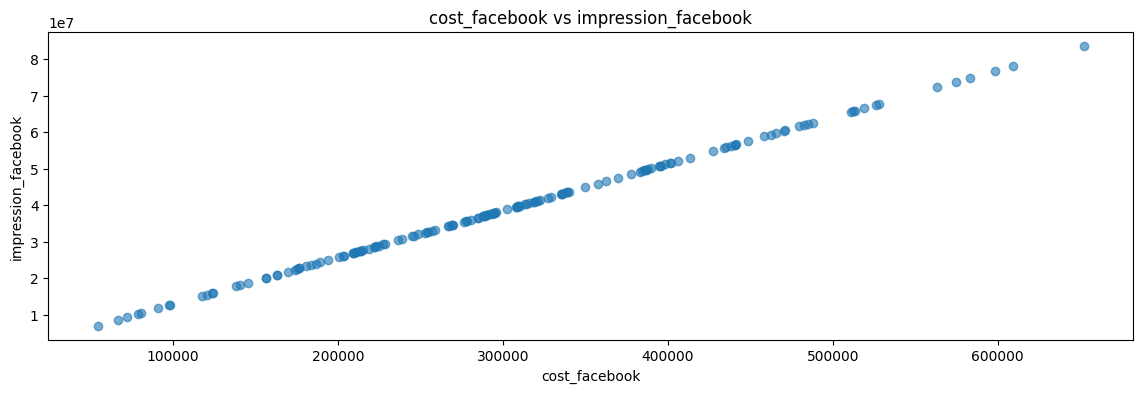

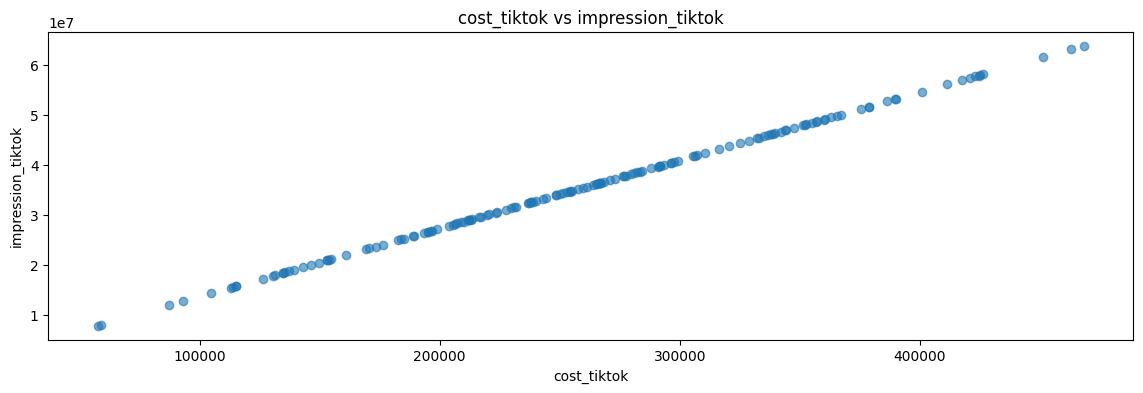

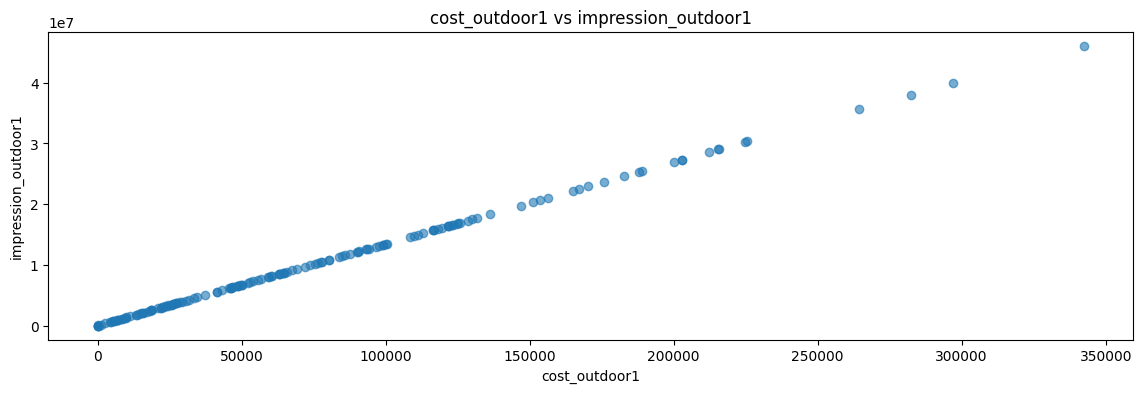

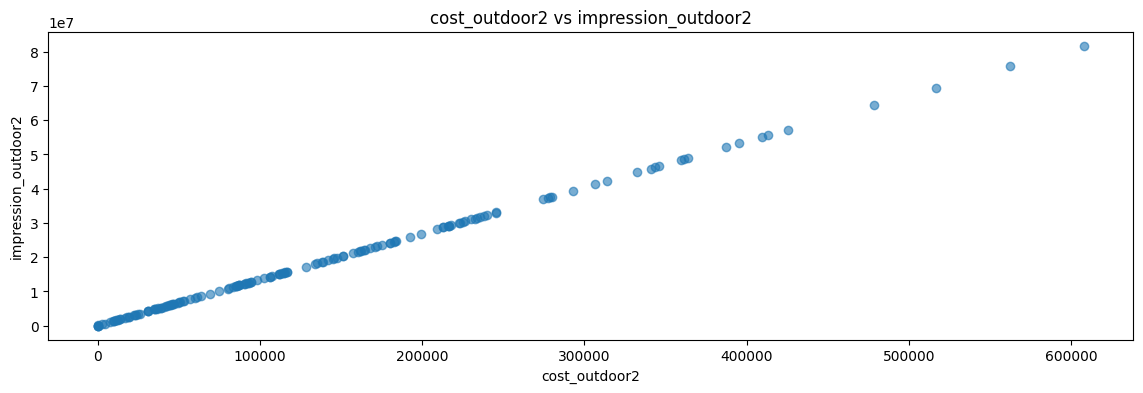

In [30]:
# media sanity check
cost_impr_channels = {
    "impression_tv": "cost_tv",
    "impression_google": "cost_google",
    "impression_facebook": "cost_facebook",
    "impression_tiktok": "cost_tiktok",
    "impression_outdoor1": "cost_outdoor1",
    "impression_outdoor2": "cost_outdoor2",
}
for impr_col, cost_col in cost_impr_channels.items():
    plt.figure(figsize=(14, 4))

    plt.scatter(weekly[cost_col], weekly[impr_col], alpha=0.6)
    plt.xlabel(cost_col)
    plt.ylabel(impr_col)
    plt.title(f"{cost_col} vs {impr_col}")
    plt.show()

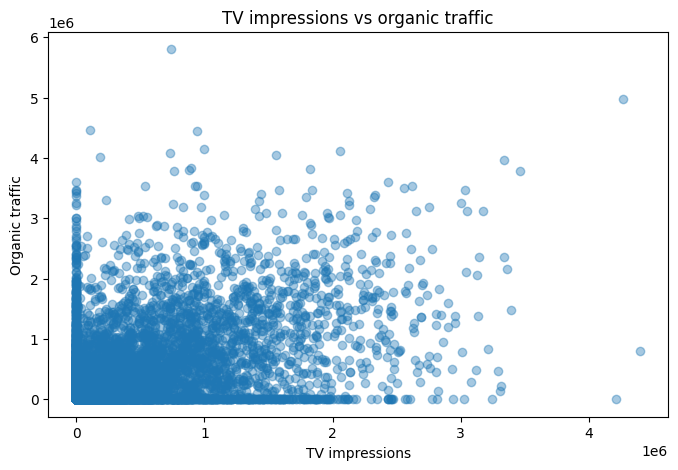

In [31]:
plt.figure(figsize=(8,5))
plt.scatter(
    cost_revenue_df["impression_tv"],
    cost_revenue_df["impression_organic"],
    alpha=0.4
)
plt.xlabel("TV impressions")
plt.ylabel("Organic traffic")
plt.title("TV impressions vs organic traffic")
plt.show()

Ekspozycja w TV nie przekłada się wprost na liniowy wzrost ruchu organicznego, jednak analiza rozkładu wskazuje, że wyższa presja reklamowa istotnie ogranicza ryzyko bardzo niskiego poziomu ruchu organicznego. Sugeruje to efekt halo oraz rolę TV w stabilizowaniu popytu i budowaniu świadomości marki. Dalszą analiza mogłoby być przesunięcie kanałów o lag (t-1, t-2) lub agregacja per capita.

## Geo-level analysis

In [32]:
cost_revenue_df["total_cost"] = (
    cost_revenue_df["cost_tv"] +
    cost_revenue_df["cost_google"] +
    cost_revenue_df["cost_facebook"] +
    cost_revenue_df["cost_tiktok"] +
    cost_revenue_df["cost_outdoor1"] +
    cost_revenue_df["cost_outdoor2"]
)

geo_summary = (
    cost_revenue_df
    .groupby("geo")
    .agg(
        revenue=("revenue", "sum"),
        population=("population", "mean"),
        conversions=("conversions", "sum"),
        total_cost=("total_cost", "sum")
    )
    .reset_index()
)

geo_summary["revenue_pc"] = geo_summary["revenue"] / geo_summary["population"]
geo_summary["total_cost_pc"] = geo_summary["total_cost"] / geo_summary["population"]

geo_summary.sort_values("revenue_pc", ascending=False)


,geo,revenue,population,conversions,total_cost,revenue_pc,total_cost_pc
33,Geo39,6.414081e+07,798939.10,3.205750e+09,8.474987e+06,80.282471,10.607801
39,Geo9,3.757402e+07,513695.22,1.878057e+09,5.865544e+06,73.144575,11.418334
37,Geo7,5.125151e+07,733989.56,2.563896e+09,8.448810e+06,69.825941,11.510805
30,Geo36,6.531835e+07,969886.50,3.265847e+09,1.084031e+07,67.346386,11.176881
22,Geo29,2.819435e+07,428704.50,1.410112e+09,4.627203e+06,65.766386,10.793455
34,Geo4,2.213635e+07,337852.20,1.107521e+09,3.535122e+06,65.520823,10.463516
15,Geo22,2.648648e+07,411040.88,1.325255e+09,4.406643e+06,64.437573,10.720694
24,Geo30,1.736297e+07,270937.94,8.680725e+08,2.885972e+06,64.084659,10.651782
38,Geo8,1.906856e+07,301630.44,9.530039e+08,3.111036e+06,63.218304,10.314064
31,Geo37,2.069761e+07,327985.06,1.034859e+09,3.601104e+06,63.105341,10.979477


In [33]:
channel_cols = [
    "cost_tv",
    "cost_google",
    "cost_facebook",
    "cost_tiktok",
    "cost_outdoor1",
    "cost_outdoor2",
]

geo_channels = (
    cost_revenue_df
    .groupby("geo")[channel_cols]
    .sum()
)

geo_channels_pct = geo_channels.div(geo_channels.sum(axis=1), axis=0)
geo_channels_pct


,cost_tv,cost_google,cost_facebook,cost_tiktok,cost_outdoor1,cost_outdoor2
geo,,,,,,
Geo0,0.143509,0.365078,0.186447,0.164785,0.050088,0.090093
Geo1,0.127797,0.351663,0.197646,0.170049,0.054206,0.098638
Geo10,0.126231,0.378216,0.205051,0.163535,0.044916,0.082051
Geo11,0.123690,0.367371,0.195270,0.169139,0.051266,0.093264
Geo12,0.134847,0.351804,0.203034,0.163615,0.052139,0.094561
Geo13,0.132082,0.371627,0.192996,0.167048,0.048497,0.087749
Geo14,0.126255,0.364083,0.196398,0.149437,0.058265,0.105562
Geo15,0.120841,0.355017,0.210260,0.163380,0.053020,0.097483
Geo16,0.123055,0.381475,0.202862,0.171331,0.043364,0.077913


Regiony nie różnią się strukturą wydatków.

# Modeling

In [34]:
# check whether a TV channel has a delayed effect
df_lag = cost_revenue_df.copy()

for lag in range(0, 6):
    df_lag[f"tv_lag_{lag}"] = (
        df_lag.groupby("geo")["cost_tv"].shift(lag)
    )

df_lag[[
    "revenue",
    "tv_lag_0",
    "tv_lag_1",
    "tv_lag_2",
    "tv_lag_3",
    "tv_lag_4",
    "tv_lag_5"
]].corr()["revenue"]


,revenue
revenue,1.000000
tv_lag_0,0.292444
tv_lag_1,0.279826
tv_lag_2,0.287249
tv_lag_3,0.296773
tv_lag_4,0.287154
tv_lag_5,0.296295


In [35]:
# calculate revenue per capita
df_model = cost_revenue_df.copy()
df_model["revenue_pc"] = df_model["revenue"] / df_model["population"]


In [36]:
# create adstock function and parameters
def adstock(series, decay):
    result = np.zeros(len(series))
    for i in range(len(series)):
        if i == 0:
            result[i] = series.iloc[i]
        else:
            result[i] = series.iloc[i] + decay * result[i-1]
    return result

adstock_params = {
    "cost_tv": 0.5,
    "cost_outdoor1": 0.4,
    "cost_outdoor2": 0.4,
    "cost_google": 0.2,
    "cost_facebook": 0.25,
    "cost_tiktok": 0.25,
}

In [37]:
# applay adstock per geo
df_model = df_model.sort_values(["geo", "week"])

for col, decay in adstock_params.items():
    df_model[f"adstock_{col}"] = (
        df_model
        .groupby("geo")[col]
        .transform(lambda x: adstock(x, decay))
    )

In [38]:
# non-linear transformation
for col in adstock_params.keys():
    df_model[f"log_{col}"] = np.log1p(df_model[f"adstock_{col}"])

df_model["log_revenue_pc"] = np.log1p(df_model["revenue_pc"])

In [39]:
# model 0 - baseline
import statsmodels.formula.api as smf

df_model["week"] = df_model["week"].astype(str)

model_0 = smf.ols(
    "log_revenue_pc ~ promo + market_share + C(geo) + C(week)",
    data=df_model
).fit()


In [40]:
# model 1 - no adstock
model_1 = smf.ols(
    """
    log_revenue_pc ~
    np.log1p(cost_tv) +
    np.log1p(cost_google) +
    np.log1p(cost_facebook) +
    np.log1p(cost_tiktok) +
    np.log1p(cost_outdoor1) +
    np.log1p(cost_outdoor2) +
    promo + market_share +
    C(geo) + C(week)
    """,
    data=df_model
).fit()

In [41]:
# model MMM - with adstock
model_mmm = smf.ols(
    """
    log_revenue_pc ~
    log_cost_tv +
    log_cost_google +
    log_cost_facebook +
    log_cost_tiktok +
    log_cost_outdoor1 +
    log_cost_outdoor2 +
    promo + market_share +
    C(geo) + C(week)
    """,
    data=df_model.rename(columns={
        "log_cost_tv": "log_cost_tv",
        "log_cost_google": "log_cost_google",
        "log_cost_facebook": "log_cost_facebook",
        "log_cost_tiktok": "log_cost_tiktok",
        "log_cost_outdoor1": "log_cost_outdoor1",
        "log_cost_outdoor2": "log_cost_outdoor2"
    })
).fit()

In [42]:
elasticities = model_mmm.params.filter(like="log_")
elasticities.sort_values(ascending=False)

,0
log_cost_google,0.011470
log_cost_outdoor1,0.011234
log_cost_facebook,0.010946
log_cost_tv,-0.000169
log_cost_tiktok,-0.002111
log_cost_outdoor2,-0.009930


In [43]:
pd.DataFrame({
    "model": ["baseline", "no_adstock", "mmm"],
    "R2": [model_0.rsquared, model_1.rsquared, model_mmm.rsquared],
    "AIC": [model_0.aic, model_1.aic, model_mmm.aic]
})

,model,R2,AIC
0,baseline,0.900077,-25894.050307
1,no_adstock,0.917934,-27102.704729
2,mmm,0.915819,-26944.928816


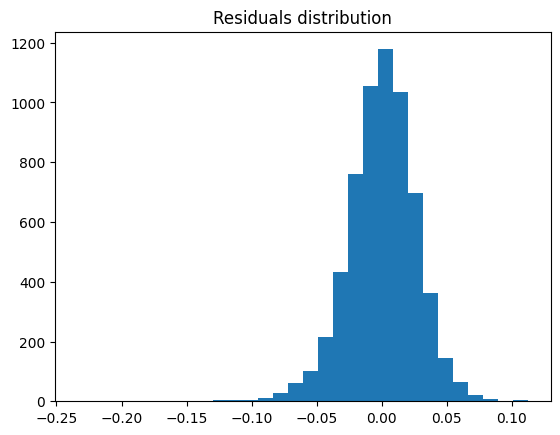

In [44]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(model_mmm.resid, bins=30)
plt.title("Residuals distribution")
plt.show()


In [45]:
model_mmm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         log_revenue_pc   R-squared:                       0.916
Model:                            OLS   Adj. R-squared:                  0.913
Method:                 Least Squares   F-statistic:                     324.6
Date:                Tue, 10 Feb 2026   Prob (F-statistic):               0.00
Time:                        21:14:35   Log-Likelihood:                 13674.
No. Observations:                6200   AIC:                        -2.694e+04
Df Residuals:                    5998   BIC:                        -2.559e+04
Df Model:                         201                                         
Covariance Type:            nonrobust                                         
=========================================================================================
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                -0.1065      0.008    -13.518      0.000      -0.122      -0.091
C(geo)[T.Geo1]           -0.0183      0.003     -5.895      0.000      -0.024      -0.012
C(geo)[T.Geo10]          -0.0011      0.003     -0.325      0.745      -0.008       0.006
C(geo)[T.Geo11]          -0.0270      0.003     -8.024      0.000      -0.034      -0.020
C(geo)[T.Geo12]          -0.0007      0.003     -0.203      0.839      -0.007       0.006
C(geo)[T.Geo13]           0.0001      0.003      0.032      0.975      -0.006       0.006
C(geo)[T.Geo14]          -0.0295      0.003     -8.637      0.000      -0.036      -0.023
C(geo)[T.Geo15]           0.0263      0.003      7.810      0.000       0.020       0.033
C(geo)[T.Geo16]           0.0136      0.003      4.244      0.000       0.007       0.020
C(geo)[T.Geo17]          -0.0111      0.003     -3.225      0.001      -0.018      -0.004
C(geo)[T.Geo18]          -0.0246      0.003     -7.424      0.000      -0.031      -0.018
C(geo)[T.Geo19]          -0.0161      0.003     -4.935      0.000      -0.022      -0.010
C(geo)[T.Geo2]           -0.0256      0.003     -7.340      0.000      -0.032      -0.019
C(geo)[T.Geo20]           0.0025      0.003      0.747      0.455      -0.004       0.009
C(geo)[T.Geo21]          -0.0430      0.003    -13.136      0.000      -0.049      -0.037
C(geo)[T.Geo22]           0.0205      0.003      6.386      0.000       0.014       0.027
C(geo)[T.Geo23]          -0.0170      0.004     -4.844      0.000      -0.024      -0.010
C(geo)[T.Geo24]           0.0213      0.003      6.894      0.000       0.015       0.027
C(geo)[T.Geo25]           0.0135      0.003      3.924      0.000       0.007       0.020
C(geo)[T.Geo26]           0.0042      0.003      1.347      0.178      -0.002       0.010
C(geo)[T.Geo27]           0.0075      0.003      2.250      0.024       0.001       0.014
C(geo)[T.Geo28]           0.0196      0.003      5.829      0.000       0.013       0.026
C(geo)[T.Geo29]           0.0367      0.003     11.356      0.000       0.030       0.043
C(geo)[T.Geo3]            0.0122      0.003      3.922      0.000       0.006       0.018
C(geo)[T.Geo30]           0.0328      0.003     10.477      0.000       0.027       0.039
C(geo)[T.Geo31]           0.0044      0.003      1.278      0.201      -0.002       0.011
C(geo)[T.Geo32]          -0.0172      0.003     -5.145      0.000      -0.024      -0.011
C(geo)[T.Geo33]           0.0063      0.003      1.905      0.057      -0.000       0.013
C(geo)[T.Geo34]           0.0054      0.003      1.629      0.103      -0.001       0.012
C(geo)[T.Geo35]          -0.0224      0.003     -6.554      0.000      -0.029      -0.016
C(geo)[T.Geo36]           0.0249      0.003      7.129      0.000       0.018       0.032
C(geo)[T.Geo37]        

# Ridge Regression

In [50]:
df_ridge = cost_revenue_df.copy()
df_ridge["week"] = pd.to_datetime(df_ridge["week"])
df_ridge.head(2)

,week,geo,impression_tiktok,impression_tv,impression_outdoor1,impression_google,impression_facebook,impression_outdoor2,impression_organic,market_share,...,cost_outdoor1,cost_google,cost_facebook,cost_outdoor2,conversions,revenue,population,promo_description,promo,total_cost
0,2022-10-03,Geo0,495955,323000,24000,895616,241546,52127,156720,0.044674,...,180.4600,6979.3926,1882.1051,387.499424,2193336.5,43971.176684,136670.94,Darmowa dostawa kurierem na wszystkie zamówienia.,1.0,16179.552624
1,2022-09-26,Geo0,316706,408000,168000,944990,384225,303251,304060,0.058172,...,1250.4092,7364.1567,2993.8472,2254.286274,2972293.8,59492.778796,136670.94,Darmowa dostawa i gratis o wartości 30 zł do z...,1.0,20120.731374


In [51]:
# adstock per geo
def adstock(x, decay):
    out = []
    carry = 0
    for v in x:
        carry = v + decay * carry
        out.append(carry)
    return out

channels = {
    "tv": "cost_tv",
    "outdoor1": "cost_outdoor1",
    "outdoor2": "cost_outdoor2",
    "google": "cost_google",
    "facebook": "cost_facebook",
    "tiktok": "cost_tiktok"
}

decay = {
    "tv": 0.8,
    "outdoor1": 0.6,
    "outdoor2": 0.6,
    "google": 0.4,
    "facebook": 0.4,
    "tiktok": 0.3
}

for ch, col in channels.items():
    df_ridge[f"{ch}_adstock"] = (
        df_ridge.groupby("geo")[col]
          .transform(lambda x: adstock(x, decay[ch]))
    )


In [62]:
# diminishing returns (log)
for ch in channels:
    df_ridge[f"{ch}_feat"] = np.log1p(df_ridge[f"{ch}_adstock"])

df_ridge["organic_feat"] = np.log1p(df_ridge["impression_organic"])

In [55]:
# sesionality
df_ridge["weekofyear"] = df_ridge["week"].dt.isocalendar().week.astype(int)
df_ridge["sin_week"] = np.sin(2 * np.pi * df_ridge["weekofyear"] / 52)
df_ridge["cos_week"] = np.cos(2 * np.pi * df_ridge["weekofyear"] / 52)

In [59]:
geo_dummies = pd.get_dummies(df_ridge["geo"], prefix="geo", drop_first=True)

In [63]:
media_feats = [f"{ch}_feat" for ch in channels]

control_feats = [
    "organic_feat",
    "promo",
    "population",
    "market_share",
    "sin_week",
    "cos_week"
]

X = pd.concat(
    [
        df_ridge[media_feats + control_feats],
        geo_dummies
    ],
    axis=1
)

y = df_ridge["revenue"]

In [67]:
split_date = df_ridge["week"].quantile(0.8)

train = df_ridge["week"] <= split_date
test  = df_ridge["week"] > split_date

X_train, X_test = X[train], X[test]
y_train, y_test = y[train], y[test]

In [68]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_percentage_error

model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=10.0))
])

model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('ridge', Ridge(alpha=10.0))])

In [69]:
pred = model.predict(X_test)
mape = mean_absolute_percentage_error(y_test, pred)
mape

0.2301137176057538

In [71]:
coefs = pd.Series(
    model.named_steps["ridge"].coef_,
    index=X.columns
)

media_coefs = coefs[media_feats].sort_values(ascending=False)
media_coefs

,0
google_feat,9702.426334
facebook_feat,9410.729321
outdoor2_feat,2520.819812
outdoor1_feat,-308.317144
tv_feat,-1259.261325
tiktok_feat,-2476.487114


In [72]:
def simulate_uplift(channel, pct=0.1):
    df_sim = df_ridge.copy()
    df_sim[channels[channel]] *= (1 + pct)

    df_sim[f"{channel}_adstock"] = (
        df_sim.groupby("geo")[channels[channel]]
              .transform(lambda x: adstock(x, decay[channel]))
    )

    df_sim[f"{channel}_feat"] = np.log1p(df_sim[f"{channel}_adstock"])

    X_sim = pd.concat(
        [
            df_sim[media_feats + control_feats],
            geo_dummies
        ],
        axis=1
    )

    return model.predict(X_sim).sum()

baseline = model.predict(X).sum()

roi = []

for ch in channels:
    new_rev = simulate_uplift(ch, 0.1)
    delta_rev = new_rev - baseline
    delta_cost = df_ridge[channels[ch]].sum() * 0.1

    roi.append({
        "channel": ch,
        "ROI_10pct": delta_rev / delta_cost
    })

roi_df = pd.DataFrame(roi).sort_values("ROI_10pct", ascending=False)
roi_df


,channel,ROI_10pct
4,facebook,1.278017
3,google,0.924695
2,outdoor2,0.070419
1,outdoor1,-0.016558
0,tv,-0.315072
5,tiktok,-0.384052
